In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.chdir('/content/drive/MyDrive/Year_project/')

In [4]:
import sys
sys.path.append('/content/drive/MyDrive/Year_project/')

In [5]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


In [30]:
from skimage import io
from pathlib import Path
import cv2
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from IPython.display import Markdown
from sklearn.base import BaseEstimator, TransformerMixin
import importlib
from tqdm import tqdm
import ml
from ml.env import DATA_ROOT
from ml.data import build_dataframe
from ml.fit import fit_pipeline_anatomies
from ml.data import build_dataframe
from ml.hog import prepare_data_for_anatomy, create_andor_return_hog_data
import pandas as pd
from tqdm.notebook import tqdm
import logging
import optuna
from sklearn.model_selection import cross_val_score
from skimage.feature import hog
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn.svm import SVC
from xgboost import XGBClassifier
from optuna.pruners import MedianPruner
from optuna.exceptions import TrialPruned
import json
from sklearn.svm import LinearSVC
from ml.ml_experiments import augmented_df, get_brightness_stats, process_images, collect_image_dimensions, hog_dataset, split_hog_features, save_resized_dataset, load_image
import kagglehub
import os
import json
import optuna
import pandas as pd
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn.cluster import KMeans

logging.getLogger().setLevel(logging.WARNING)
RANDOM_STATE = 42

In [25]:
# Загрузка датафрейма с изображениями
df_images = build_dataframe(DATA_ROOT, return_images=True)
print(f"Загружено {len(df_images)} изображений.")

Обработка анатомий в valid: 100%|██████████| 7/7 [05:13<00:00, 44.86s/it]

Загружено 37108 изображений.


Считаем HOG и сохраняем

In [26]:
for anatomy in df_images["anatomy"].unique():
    create_andor_return_hog_data(
        images_df=df_images,
        anatomy=anatomy,
        is_images=True
    )

In [27]:
anatomies = df_images["anatomy"].unique()
print(anatomies)

['XR_WRIST' 'XR_FINGER' 'XR_SHOULDER' 'XR_HAND' 'XR_FOREARM' 'XR_HUMERUS'
 'XR_ELBOW']


Путь и функции для сохранения и загрузки лучших параметров

In [7]:
PARAMS_PATH = "/content/drive/MyDrive/Year_project/optuna_best_params.json"

def load_params():
    if os.path.exists(PARAMS_PATH):
        with open(PARAMS_PATH, "r") as f:
            return json.load(f)
    return {}

def save_params(params):

    with open(PARAMS_PATH, "w") as f:
        json.dump(params, f, indent=2)

Загрузка посчитанных HOG

In [8]:
data_cache = {}
def get_anatomy_data(anatomy):

    if anatomy not in data_cache:

        X_train, y_train, X_val, y_val = prepare_data_for_anatomy(
            df_images,
            anatomy=anatomy,
            is_images=True
        )

        data_cache[anatomy] = (X_train, y_train, X_val, y_val)

    return data_cache[anatomy]

Optuna, которая подбирает наилучшую модель с наилучшими параметрами для каждой анатомии отдельно

In [9]:
def objective(trial, X_train, y_train, X_val, y_val):

    model_name = trial.suggest_categorical(
        "model",
        ["logreg", "linearsvc", "xgb"]
    )

    pca = trial.suggest_int("pca", 30, 100)

    if model_name == "logreg":
        C = trial.suggest_float("C", 1e-4, 3, log=True)
        solver = trial.suggest_categorical("solver", ["lbfgs", "liblinear"])

        model = LogisticRegression(
            C=C,
            solver=solver,
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )

    elif model_name == "linearsvc":
        C = trial.suggest_float("C", 1e-4, 20, log=True)

        model = LinearSVC(
            C=C,
            loss="squared_hinge",
            class_weight="balanced",
            max_iter=50000,
            dual=False,
            random_state=RANDOM_STATE
        )

    elif model_name == "xgb":
        model = XGBClassifier(
            learning_rate=trial.suggest_float("learning_rate", 0.03, 0.2),
            max_depth=trial.suggest_int("max_depth", 3, 6),
            n_estimators=trial.suggest_int("n_estimators", 80, 250),
            subsample=trial.suggest_float("subsample", 0.7, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
            tree_method="hist",
            eval_metric="logloss",
            n_jobs=2,
            random_state=RANDOM_STATE
        )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=pca,
            svd_solver="randomized",
            random_state=RANDOM_STATE
        )),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)

    if model_name == "linearsvc":
        scores = pipe.decision_function(X_val)
        kappa, best_t = best_threshold(y_val, scores, is_probability=False)
    else:
        proba = pipe.predict_proba(X_val)[:, 1]
        kappa, best_t = best_threshold(y_val, proba, is_probability=True)

    trial.set_user_attr("best_threshold", best_t)
    return kappa

Функция запуска Optuna

In [10]:
def train_best_model_for_anatomy(anatomy):

    X_train, y_train, X_val, y_val = get_anatomy_data(anatomy)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=5
        )
    )

    study.optimize(
        lambda trial: objective(trial, X_train, y_train, X_val, y_val),
        n_trials=60,
        show_progress_bar=True
    )

    best_params = study.best_params
    best_params["threshold"] = study.best_trial.user_attrs["best_threshold"]

    return study.best_value, best_params

Функция построения модели

In [11]:
def build_model(params):

    model_name = params["model"]

    if model_name == "logreg":
        clf = LogisticRegression(
            C=params["C"],
            solver=params["solver"],
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )

    elif model_name == "linearsvc":
        clf = LinearSVC(
            C=params["C"],
            loss="squared_hinge",
            class_weight="balanced",
            max_iter=50000,
            dual=False,
            random_state=RANDOM_STATE
        )

    elif model_name == "xgb":
        clf = XGBClassifier(
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            n_estimators=params["n_estimators"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            tree_method="hist",
            eval_metric="logloss",
            n_jobs=2,
            random_state=RANDOM_STATE
        )

    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=params["pca"],
            svd_solver="randomized",
            random_state=RANDOM_STATE
        )),
        ("clf", clf)
    ])

Функция для обучения модели с универсальной Optuna

In [12]:
def train_model_family(anatomies):

    params_storage = load_params()

    results = []

    for anatomy in anatomies:

        if anatomy in params_storage:

            print(f"{anatomy} already trained → skip")
            params = params_storage[anatomy]

        else:

            print(f"\nTraining → {anatomy}")

            kappa, params = train_best_model_for_anatomy(anatomy)

            params_storage[anatomy] = params
            save_params(params_storage)

        X_train, y_train, X_val, y_val = get_anatomy_data(anatomy)

        model = build_model(params)

        model.fit(X_train, y_train)

        threshold = params["threshold"]

        if params["model"] == "linearsvc":
            scores = model.decision_function(X_val)
            y_pred = (scores > threshold).astype(int)
        else:
            proba = model.predict_proba(X_val)[:,1]
            y_pred = (proba > threshold).astype(int)

        kappa = cohen_kappa_score(y_val, y_pred)
        acc = accuracy_score(y_val, y_pred)

        results.append({
            "anatomy": anatomy,
            "model": params["model"],
            "kappa": kappa,
            "accuracy": acc,
            "params": params
        })

    return pd.DataFrame(results)

In [13]:
def best_threshold(y_true, scores, is_probability=True):
    if is_probability:
        thresholds = np.linspace(0.1, 0.9, 50)
    else:
        thresholds = np.linspace(-1.0, 1.0, 50)

    best_kappa = -1
    best_t = 0.5 if is_probability else 0.0

    for t in thresholds:
        y_pred = (scores > t).astype(int)
        k = cohen_kappa_score(y_true, y_pred)
        if k > best_kappa:
            best_kappa = k
            best_t = t

    return best_kappa, best_t

In [14]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

In [36]:
results_df = train_model_family(anatomies)


Training → XR_WRIST


[I 2026-03-31 22:43:09,231] A new study created in memory with name: no-name-83126b85-4d5c-4ecf-9293-708127baeb1f


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-03-31 22:43:35,406] Trial 0 finished with value: 0.3978414124399525 and parameters: {'model': 'linearsvc', 'pca': 72, 'C': 0.0006715208365130138}. Best is trial 0 with value: 0.3978414124399525.
[I 2026-03-31 22:44:00,116] Trial 1 finished with value: 0.4553421592392317 and parameters: {'model': 'xgb', 'pca': 72, 'learning_rate': 0.15037233822532775, 'max_depth': 3, 'n_estimators': 245, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7637017332034828}. Best is trial 1 with value: 0.4553421592392317.
[I 2026-03-31 22:44:26,730] Trial 2 finished with value: 0.4269162753826453 and parameters: {'model': 'xgb', 'pca': 67, 'learning_rate': 0.10343065316915968, 'max_depth': 4, 'n_estimators': 184, 'subsample': 0.7418481581956126, 'colsample_bytree': 0.7876433945605654}. Best is trial 1 with value: 0.4553421592392317.
[I 2026-03-31 22:44:49,543] Trial 3 finished with value: 0.4268239541832669 and parameters: {'model': 'xgb', 'pca': 44, 'learning_rate': 0.11741985453031398, 'max_

[I 2026-03-31 23:08:42,185] A new study created in memory with name: no-name-879ba6bc-ab59-4243-8a09-9e2ec177fe87


...

  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-04-01 00:17:03,697] Trial 0 finished with value: 0.2139130434782609 and parameters: {'model': 'xgb', 'pca': 70, 'learning_rate': 0.09598888745510872, 'max_depth': 5, 'n_estimators': 158, 'subsample': 0.8636850367947805, 'colsample_bytree': 0.9824394426329576}. Best is trial 0 with value: 0.2139130434782609.
[I 2026-04-01 00:17:08,020] Trial 1 finished with value: 0.2960309777347532 and parameters: {'model': 'linearsvc', 'pca': 43, 'C': 0.00023317733610946228}. Best is trial 1 with value: 0.2960309777347532.
[I 2026-04-01 00:17:12,580] Trial 2 finished with value: 0.2859618717504333 and parameters: {'model': 'logreg', 'pca': 78, 'C': 0.00020831484079402544, 'solver': 'liblinear'}. Best is trial 1 with value: 0.2960309777347532.
[I 2026-04-01 00:17:15,568] Trial 3 finished with value: 0.28097731239092494 and parameters: {'model': 'linearsvc', 'pca': 38, 'C': 0.49365621915249625}. Best is trial 1 with value: 0.2960309777347532.
[I 2026-04-01 00:17:22,538] Trial 4 finished with val

[I 2026-04-01 00:21:55,152] A new study created in memory with name: no-name-dd5d13d8-56e1-4eb6-9749-09bcf5ac6bb5


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-04-01 00:22:12,686] Trial 0 finished with value: 0.22762492460446337 and parameters: {'model': 'linearsvc', 'pca': 93, 'C': 0.00724788021969433}. Best is trial 0 with value: 0.22762492460446337.
[I 2026-04-01 00:22:28,843] Trial 1 finished with value: 0.2429232192414431 and parameters: {'model': 'xgb', 'pca': 73, 'learning_rate': 0.04719085494087434, 'max_depth': 3, 'n_estimators': 199, 'subsample': 0.721828901909258, 'colsample_bytree': 0.9465580177871069}. Best is trial 1 with value: 0.2429232192414431.
[I 2026-04-01 00:22:45,488] Trial 2 finished with value: 0.21913995453912882 and parameters: {'model': 'logreg', 'pca': 100, 'C': 0.004738662025302394, 'solver': 'liblinear'}. Best is trial 1 with value: 0.2429232192414431.
[I 2026-04-01 00:22:58,696] Trial 3 finished with value: 0.19820153888940395 and parameters: {'model': 'linearsvc', 'pca': 56, 'C': 0.0002771020915855572}. Best is trial 1 with value: 0.2429232192414431.
[I 2026-04-01 00:23:15,519] Trial 4 finished with val

In [37]:
pd.DataFrame(results_df)

,anatomy,model,kappa,accuracy,params
0,XR_WRIST,xgb,0.484941,0.746063,"{'model': 'xgb', 'pca': 54, 'learning_rate': 0..."
1,XR_FINGER,xgb,0.548731,0.776573,"{'model': 'xgb', 'pca': 76, 'learning_rate': 0..."
2,XR_SHOULDER,xgb,0.311636,0.657194,"{'model': 'xgb', 'pca': 98, 'learning_rate': 0..."
3,XR_HAND,logreg,0.340155,0.673913,"{'model': 'logreg', 'pca': 95, 'C': 0.00826099..."
4,XR_FOREARM,logreg,0.322850,0.661130,"{'model': 'logreg', 'pca': 32, 'C': 0.00010213..."
5,XR_HUMERUS,logreg,0.317865,0.659722,"{'model': 'logreg', 'pca': 30, 'C': 0.00047686..."
6,XR_ELBOW,xgb,0.338537,0.668817,"{'model': 'xgb', 'pca': 58, 'learning_rate': 0..."


In [38]:
print('Средний Kappa по всем анатомиям:', results_df['kappa'].mean())
print('Средний Accuracy по всем анатомиям:', results_df['accuracy'].mean())

Средний Kappa по всем анатомиям: 0.3806734434999516
Средний Accuracy по всем анатомиям: 0.6919159005757842


Сравним результаты со всеми предыдущими экспериментами. (Heatmap с предыдущими экспериментами взяли из ноутбука ML)

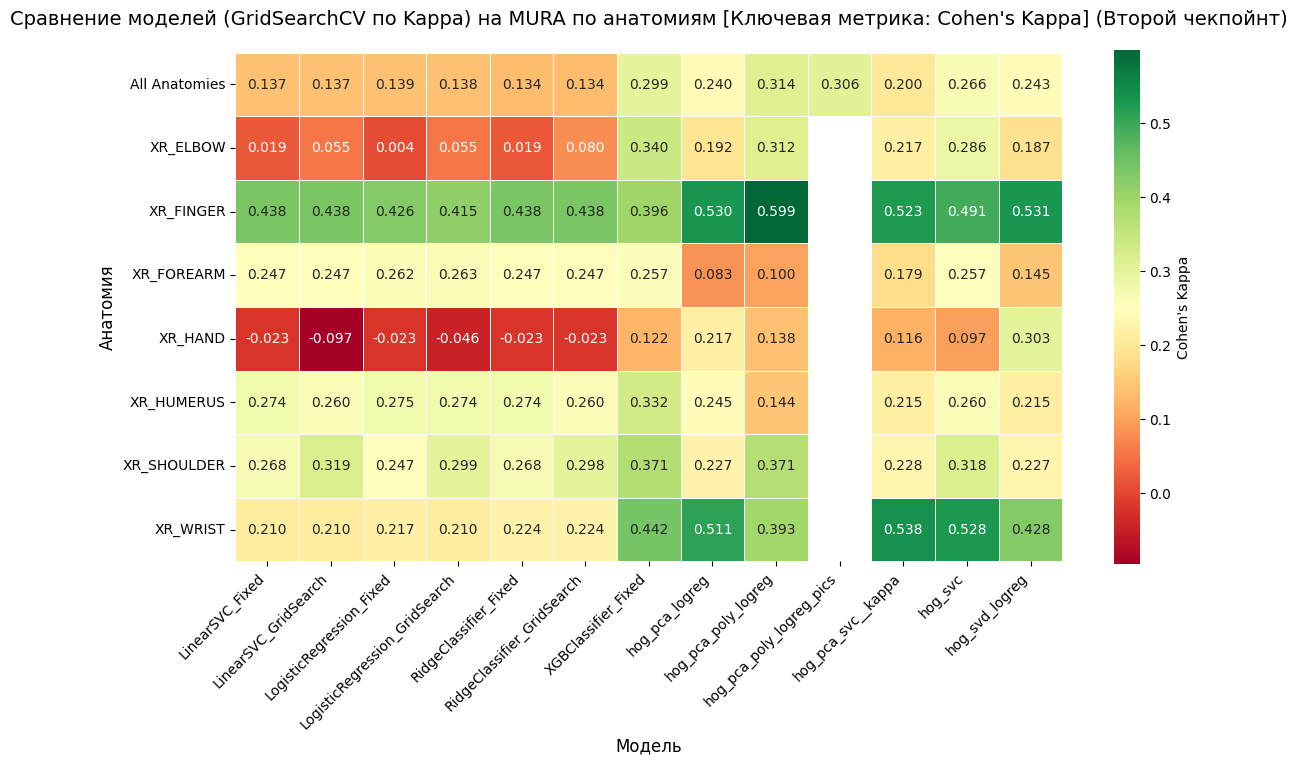

Подбор гиперпараметров с Оптуна помог улучшить качество на таких анатомиях, как XR_FOREARM и XR_HAND. XR_ELBOW показал тот же результат.

In [ ]:
# лучшие результаты по всем проведенным экспериментам
metrics = {
    'XR_ELBOW' : 0.34,
    'XR_FINGER':0.60,
    'XR_FOREARM':0.32,
    'XR_HAND':0.34,
    'XR_HUMERUS':0.33,
    'XR_SHOULDER':0.37,
    'XR_WRIST':0.54
}
pd.DataFrame([metrics])

,XR_ELBOW,XR_FINGER,XR_FOREARM,XR_HAND,XR_HUMERUS,XR_SHOULDER,XR_WRIST
0,0.34,0.6,0.32,0.34,0.33,0.37,0.54


XR_ELBOW, XR_FOREARM, XR_HAND, XR_HUMERUS и XR_SHOULDER показывают слабый результат. Вспомним распределение таргета и количество исследований по каждой анатомии. (Графики из ноутбука EDA)
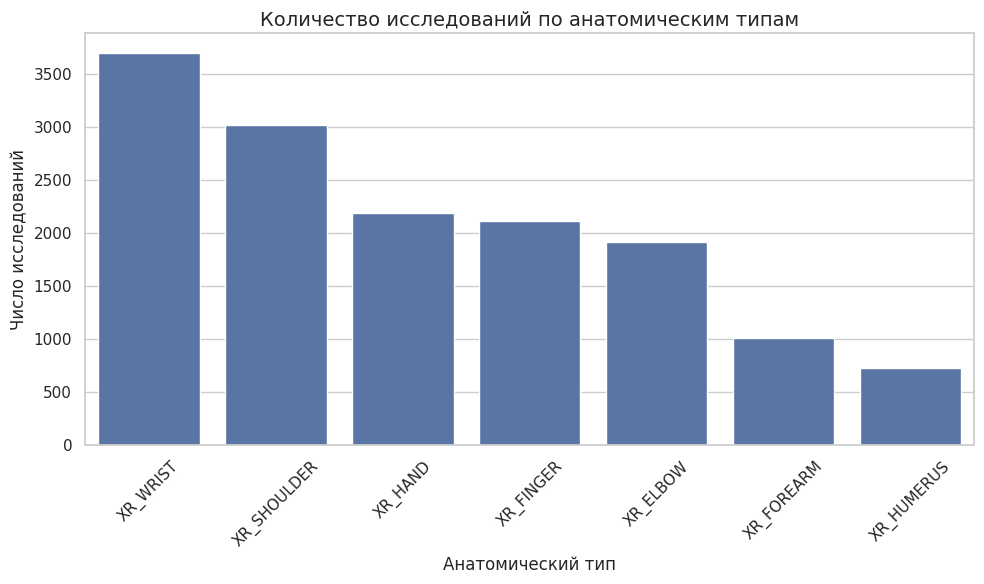
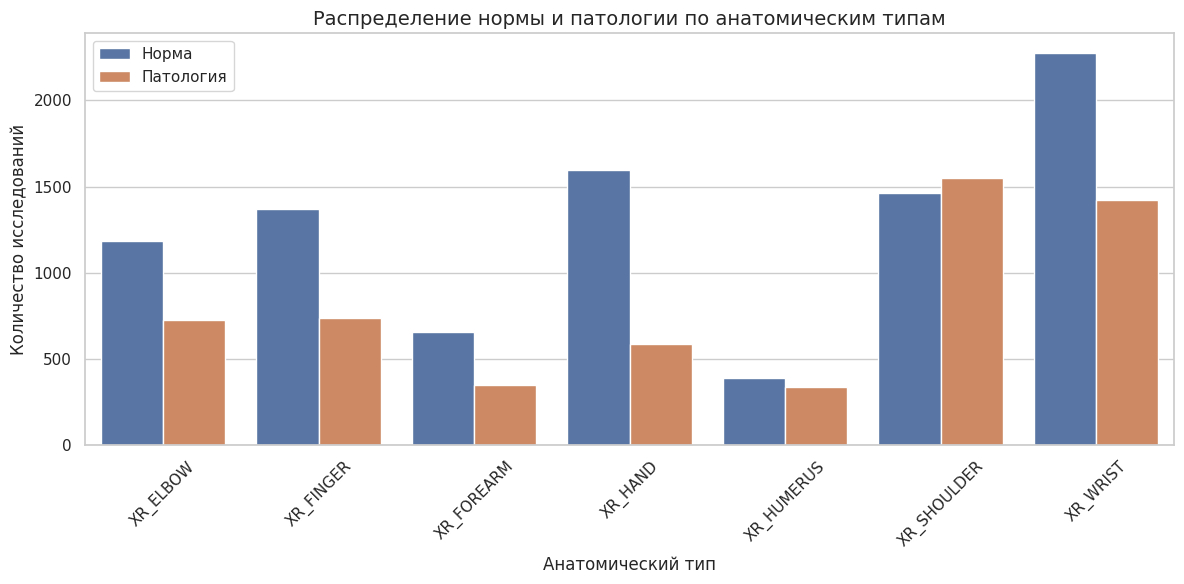

Из всех анатомий с низкими метриками, можно выделить XR_FOREARM и XR_HUMERUS, которые имеют наименьшее количество исследований. Можно предположить, что на результат влияет недостаточное количество обучающих данных. С помощью аугментации попробуем искуственно увеличить датасет для этих анатомий.

Так как с рентген снимками нужно работать аккуратно, применяем небольшой поворот изображения на 8 градусов и добавление шума. Изменения применяем к оригинальным изображениям, а качество и ресайз делаем после аугментации.

In [ ]:
# загрузка сырого датасета из Kaggle
path = kagglehub.dataset_download("cjinny/mura-v11")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mura-v11' dataset.
Path to dataset files: /kaggle/input/mura-v11


In [ ]:
raw_data = os.path.join(path, "MURA-v1.1")
augment_anatomies = ["XR_FOREARM", "XR_HUMERUS"]

# из всех анатомий берем только необходимые
raw_df = build_dataframe(raw_data, return_images=True)
raw_df = raw_df[raw_df["anatomy"].isin(augment_anatomies)].copy()
print(f"Загружено {len(raw_df)} изображений.")
print(raw_df["anatomy"].value_counts())

Обработка анатомий в valid: 100%|██████████| 7/7 [00:07<00:00,  1.08s/it]

Загружено 3686 изображений.
anatomy
XR_FOREARM    2126
XR_HUMERUS    1560
Name: count, dtype: int64


Аугментация

In [ ]:
AUG_DIR = "/content/drive/MyDrive/Year_project/augmented_images"
os.makedirs(AUG_DIR, exist_ok=True)

df_aug = augmented_df(raw_df, AUG_DIR, augment_anatomies)

Сохранение XR_HUMERUS: 100%|██████████| 1560/1560 [02:31<00:00, 10.31it/s]


Извлечение статистики яркости и улучшение качества

In [ ]:
augm_path = Path("/content/drive/MyDrive/Year_project/augmented_images")
image_paths = list(augm_path.rglob("*.png"))
print("Найдено файлов:", len(image_paths))

Найдено файлов: 6783


In [ ]:
brightness_data = []

for path in tqdm(image_paths, desc='Извлечение статистики яркости'):
    stats = get_brightness_stats(path)
    if stats:
        brightness_data.append({**stats, 'path': path})

brightness_df = pd.DataFrame(brightness_data)

Извлечение статистики яркости: 100%|██████████| 6783/6783 [01:42<00:00, 66.08it/s]


In [ ]:
output_dir = "/content/drive/MyDrive/Year_project/enhanced_images"
process_images(brightness_df, str(augm_path), output_dir)

Обработка изображений: 100%|██████████| 6783/6783 [06:24<00:00, 17.65it/s]


Ресайз

In [ ]:
extensions = {".png", ".jpg", ".jpeg"}

df_dimensions = collect_image_dimensions(Path(output_dir), extensions)
display(df_dimensions.head())

X = df_dimensions[["aspect_ratio"]].values

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

df_dimensions["ar_cluster"] = kmeans.fit_predict(X)

cluster_stats = (
    df_dimensions
    .groupby("ar_cluster")
    .agg(
        count=("aspect_ratio", "size"),
        mean_ar=("aspect_ratio", "mean"),
        median_ar=("aspect_ratio", "median"),
        std_ar=("aspect_ratio", "std"),
        mean_w=("width", "mean"),
        median_w=("width", "median"),
        std_w=("width", "std"),
        mean_h=("height", "mean"),
        median_h=("height", "median"),
        std_h=("height", "std"),
    )
)
display(cluster_stats)

Всего найдено изображений: 6783


,path,width,height,aspect_ratio
0,/content/drive/MyDrive/Year_project/enhanced_i...,406,512,0.792969
1,/content/drive/MyDrive/Year_project/enhanced_i...,406,512,0.792969
2,/content/drive/MyDrive/Year_project/enhanced_i...,406,512,0.792969
3,/content/drive/MyDrive/Year_project/enhanced_i...,512,420,1.219048
4,/content/drive/MyDrive/Year_project/enhanced_i...,420,512,0.820312


,count,mean_ar,median_ar,std_ar,mean_w,median_w,std_w,mean_h,median_h,std_h
ar_cluster,,,,,,,,,,
0,5448,0.793535,0.820312,0.160947,406.179332,420.0,82.257259,511.891153,512.0,0.928552
1,365,2.557619,2.473430,0.417424,512.000000,512.0,0.000000,205.172603,207.0,31.213028
2,970,1.291692,1.219048,0.173707,512.000000,512.0,0.000000,402.129897,420.0,43.177862


In [ ]:
target_h = 224
target_w = 224

input_root= "/content/drive/MyDrive/Year_project/enhanced_images"
output_root = Path(f"Resized-{target_h}x{target_w}")
output_root.mkdir(parents=True, exist_ok=True)

save_resized_dataset(df_dimensions, input_root, output_root, target_h, target_w)

Ресайз изображений...: 100%|██████████| 6783/6783 [04:55<00:00, 22.97it/s]

Готово! Сохранено изображений: 6783


Считаем HOG на аугментированных изображениях

In [16]:
from pathlib import Path
import pandas as pd

def build_resized_dataframe(root_dir):
    root_dir = Path(root_dir)
    records = []

    for source in ["original", "augmented"]:
        source_path = root_dir / source
        if not source_path.exists():
            continue

        for split_dir in ["train", "valid"]:
            split_path = source_path / split_dir
            if not split_path.exists():
                continue

            for anatomy_path in split_path.iterdir():
                if not anatomy_path.is_dir():
                    continue
                anatomy = anatomy_path.name

                for patient_path in anatomy_path.iterdir():
                    if not patient_path.is_dir():
                        continue
                    patient_id = patient_path.name

                    for study_path in patient_path.iterdir():
                        if not study_path.is_dir():
                            continue
                        study_id = study_path.name
                        label = 1 if "positive" in study_id.lower() else 0

                        for img_path in study_path.glob("*.png"):
                            records.append({
                                "path": str(img_path),
                                "split": split_dir,
                                "anatomy": anatomy,
                                "patient_id": patient_id,
                                "study_id": study_id,
                                "label": label,
                                "source": source
                            })

    return pd.DataFrame(records)

In [17]:
resized_root = "/content/drive/MyDrive/Year_project/Resized-224x224"
resized_df = build_resized_dataframe(resized_root)

print(resized_df.shape)
print(resized_df.columns.tolist())
display(resized_df.head())


(6783, 7)
['path', 'split', 'anatomy', 'patient_id', 'study_id', 'label', 'source']


,path,split,anatomy,patient_id,study_id,label,source
0,/content/drive/MyDrive/Year_project/Resized-22...,train,XR_FOREARM,patient05601,study1_positive,1,original
1,/content/drive/MyDrive/Year_project/Resized-22...,train,XR_FOREARM,patient05601,study1_positive,1,original
2,/content/drive/MyDrive/Year_project/Resized-22...,train,XR_FOREARM,patient05601,study1_positive,1,original
3,/content/drive/MyDrive/Year_project/Resized-22...,train,XR_FOREARM,patient06858,study1_negative,0,original
4,/content/drive/MyDrive/Year_project/Resized-22...,train,XR_FOREARM,patient06858,study1_negative,0,original


In [18]:
new_hog_df = hog_dataset(resized_df, ["XR_FOREARM", "XR_HUMERUS"])

In [ ]:
# сохранение статистик
save_path = "/content/drive/MyDrive/Year_project/new_hog_df.pkl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

new_hog_df.to_pickle(save_path)

Посмотрим, изменится ли качество моделей с лучшими параметрами, если применить их к данным с аугментацией. Загрузим лучшие параметры, подобранные optuna и обучим модели.

In [ ]:
def train_augmented(hog_df: pd.DataFrame, anatomies):
    params_storage = load_params()
    results = []

    for anatomy in tqdm(anatomies, desc="Идет обучение..."):
        params = params_storage[anatomy]

        X_train, y_train, X_val, y_val = split_hog_features(hog_df, anatomy)

        model = build_model(params)
        model.fit(X_train, y_train)

        threshold = params["threshold"]

        if params["model"] == "linearsvc":
            scores = model.decision_function(X_val)
            y_pred = (scores > threshold).astype(int)
        else:
            proba = model.predict_proba(X_val)[:, 1]
            y_pred = (proba > threshold).astype(int)

        kappa = cohen_kappa_score(y_val, y_pred)
        acc = accuracy_score(y_val, y_pred)

        results.append({
            "anatomy": anatomy,
            "model": params["model"],
            "kappa": kappa,
            "accuracy": acc,
            "threshold": threshold
        })

    return pd.DataFrame(results)

Обучим модели

In [40]:
results_aug = train_augmented(new_hog_df, ["XR_FOREARM", "XR_HUMERUS"])
results_aug

Идет обучение...:   0%|          | 0/2 [00:00<?, ?it/s]

,anatomy,model,kappa,accuracy,threshold
0,XR_FOREARM,logreg,0.276426,0.637874,0.557143
1,XR_HUMERUS,logreg,0.290023,0.645833,0.524490


Получилось даже заметно хуже, чем изначально. Попробуем еще раз подобрать параметры уже для аугментированного датасета.

In [ ]:
PARAMS_PATH = "/content/drive/MyDrive/Year_project/optuna_augmented_params.json"

In [ ]:
results_df = train_model_family(augment_anatomies, new_hog_df)

[I 2026-03-29 20:08:38,355] A new study created in memory with name: no-name-9d8ebbeb-8265-4cc1-89e0-1cb8dd35baa5



Training → XR_FOREARM


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-03-29 20:08:44,162] Trial 0 finished with value: 0.22321723978207642 and parameters: {'model': 'linearsvc', 'pca': 72, 'C': 0.0006715208365130138}. Best is trial 0 with value: 0.22321723978207642.
[I 2026-03-29 20:08:54,064] Trial 1 finished with value: 0.19694397283531406 and parameters: {'model': 'xgb', 'pca': 72, 'learning_rate': 0.15037233822532775, 'max_depth': 3, 'n_estimators': 245, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7637017332034828}. Best is trial 0 with value: 0.22321723978207642.
[I 2026-03-29 20:09:01,077] Trial 2 finished with value: 0.20979946612543854 and parameters: {'model': 'xgb', 'pca': 67, 'learning_rate': 0.10343065316915968, 'max_depth': 4, 'n_estimators': 184, 'subsample': 0.7418481581956126, 'colsample_bytree': 0.7876433945605654}. Best is trial 0 with value: 0.22321723978207642.
[I 2026-03-29 20:09:09,783] Trial 3 finished with value: 0.20903168819697482 and parameters: {'model': 'xgb', 'pca': 44, 'learning_rate': 0.11741985453031398

[I 2026-03-29 20:14:59,392] A new study created in memory with name: no-name-70f9ccbe-1191-4cd8-bdfc-7009f81004cb


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-03-29 20:15:02,503] Trial 0 finished with value: 0.2624661770390414 and parameters: {'model': 'logreg', 'pca': 34, 'C': 0.0024677750121404095, 'solver': 'liblinear'}. Best is trial 0 with value: 0.2624661770390414.
[I 2026-03-29 20:15:05,589] Trial 1 finished with value: 0.28097731239092494 and parameters: {'model': 'linearsvc', 'pca': 38, 'C': 0.6038540887873589}. Best is trial 1 with value: 0.28097731239092494.
[I 2026-03-29 20:15:13,648] Trial 2 finished with value: 0.2872670807453417 and parameters: {'model': 'xgb', 'pca': 65, 'learning_rate': 0.11886458099493899, 'max_depth': 4, 'n_estimators': 84, 'subsample': 0.7323674280979913, 'colsample_bytree': 0.7094287557060203}. Best is trial 2 with value: 0.2872670807453417.
[I 2026-03-29 20:15:18,720] Trial 3 finished with value: 0.2373177842565597 and parameters: {'model': 'logreg', 'pca': 94, 'C': 0.0013065063887871186, 'solver': 'liblinear'}. Best is trial 2 with value: 0.2872670807453417.
[I 2026-03-29 20:15:23,327] Trial 4 

In [ ]:
results_df

,anatomy,model,kappa,accuracy,params
0,XR_FOREARM,logreg,0.322850,0.661130,"{'model': 'logreg', 'pca': 32, 'C': 0.00011690..."
1,XR_HUMERUS,logreg,0.317865,0.659722,"{'model': 'logreg', 'pca': 30, 'C': 0.00039199..."


С помощью аугментации не удалось добиться улучшения ни с теми же параметрами, ни в процессе подбора новых.

Далее можно попробовать подобрать гиперпараметры более точечно, проанализировав модели, которые уже были подобраны изначально. Для этого для каждой анатомии возьмем лучшую модель и подберем параметры под нее более аккуратно.

In [20]:
PARAMS_PATH = "/content/drive/MyDrive/Year_project/optuna_best_params.json"
params_storage = load_params()

За основу берем лучшие параметры и модели, подобранные универсальной Optuna для каждой анатомии, и подбираем новые параметры точечно в их окрестностях

In [21]:
# загрузка посчитанных hog
HOG_DIR = "/content/drive/MyDrive/Year_project/data"

def load_hog_data_for_anatomy(anatomy, is_images=True):
  if is_images:
        filename = f"hog_{anatomy}_images.npz"
  hog_filepath = os.path.join(HOG_DIR, filename)
  return np.load(hog_filepath, allow_pickle=True)

# деление на train и val
def get_anatomy_data_from_hog(anatomy, is_images=True):
    data = load_hog_data_for_anatomy(anatomy, is_images=is_images)

    X = data["X"].astype(np.float32)
    y = data["y"]
    splits = data["splits"]

    X_train = X[np.array(splits) == "train"]
    y_train = y[np.array(splits) == "train"]
    X_val = X[np.array(splits) == "valid"]
    y_val = y[np.array(splits) == "valid"]

    return X_train, y_train, X_val, y_val


In [22]:
def best_params_grid(trial, anatomy, params_storage):
    base = params_storage[anatomy]
    model_name = base["model"]

    if model_name == "logreg":
        return {
            "model": "logreg",
            "pca": trial.suggest_int(
                "pca",
                max(10, base["pca"] - 15),
                min(160, base["pca"] + 15)
            ),
            "C": trial.suggest_float(
                "C",
                max(base["C"] / 10, 1e-6),
                base["C"] * 10,
                log=True
            ),
            "solver": trial.suggest_categorical(
                "solver",
                sorted(list(set([base["solver"], "liblinear", "lbfgs"])))
            ),
            "threshold": trial.suggest_float(
                "threshold",
                max(0.35, base["threshold"] - 0.08),
                min(0.75, base["threshold"] + 0.08)
            )
        }

    elif model_name == "xgb":
        return {
            "model": "xgb",
            "pca": trial.suggest_int(
                "pca",
                max(10, base["pca"] - 20),
                min(160, base["pca"] + 20)
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                max(0.01, base["learning_rate"] / 2),
                min(0.4, base["learning_rate"] * 2),
                log=True
            ),
            "max_depth": trial.suggest_int(
                "max_depth",
                max(3, base["max_depth"] - 2),
                min(10, base["max_depth"] + 2)
            ),
            "n_estimators": trial.suggest_int(
                "n_estimators",
                max(50, base["n_estimators"] - 80),
                min(500, base["n_estimators"] + 80)
            ),
            "subsample": trial.suggest_float(
                "subsample",
                max(0.5, base["subsample"] - 0.15),
                min(1.0, base["subsample"] + 0.15)
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                max(0.5, base["colsample_bytree"] - 0.15),
                min(1.0, base["colsample_bytree"] + 0.15)
            ),
            "threshold": trial.suggest_float(
                "threshold",
                max(0.20, base["threshold"] - 0.10),
                min(0.80, base["threshold"] + 0.10)
            )
        }

    else:
        raise ValueError(f"Unsupported model: {model_name}")

def objective_local(trial, anatomy, params_storage):
    params = best_params_grid(trial, anatomy, params_storage)

    X_train, y_train, X_val, y_val = get_anatomy_data_from_hog(anatomy, is_images=True)

    model = build_model(params)
    model.fit(X_train, y_train)

    threshold = params["threshold"]

    if params["model"] in ["xgb", "logreg"]:
        proba = model.predict_proba(X_val)[:, 1]
        y_pred = (proba > threshold).astype(int)
    elif params["model"] == "linearsvc":
        scores = model.decision_function(X_val)
        y_pred = (scores > threshold).astype(int)
    else:
        raise ValueError(f"Unsupported model: {params['model']}")

    kappa = cohen_kappa_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)

    trial.set_user_attr("accuracy", acc)
    return kappa

def run_local_optuna_for_anatomy(anatomy, params_storage, n_trials=30):
    study = optuna.create_study(
        direction="maximize",
        study_name=f"local_{anatomy}"
    )

    study.optimize(
        lambda trial: objective_local(trial, anatomy, params_storage),
        n_trials=n_trials,
        show_progress_bar=True
    )

    best_params = study.best_params.copy()
    best_params["model"] = params_storage[anatomy]["model"]

    return {
        "anatomy": anatomy,
        "model": best_params["model"],
        "kappa": study.best_value,
        "accuracy": study.best_trial.user_attrs["accuracy"],
        "params": best_params
    }

Сохранение лучших параметров

In [24]:
results = []

for anatomy in params_storage.keys():
    print(f"Running Optuna for {anatomy}...")
    result = run_local_optuna_for_anatomy(anatomy, params_storage, n_trials=30)
    results.append(result)

results_df = pd.DataFrame(results)
results_df

[I 2026-04-01 09:58:54,074] A new study created in memory with name: local_XR_WRIST


Running Optuna for XR_WRIST...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-01 10:00:06,556] Trial 0 finished with value: 0.3726986977997305 and parameters: {'pca': 57, 'learning_rate': 0.03201854866583759, 'max_depth': 4, 'n_estimators': 231, 'subsample': 0.8897130950404575, 'colsample_bytree': 0.9460942616296057, 'threshold': 0.55599926063655}. Best is trial 0 with value: 0.3726986977997305.
[I 2026-04-01 10:01:07,964] Trial 1 finished with value: 0.42615647118301314 and parameters: {'pca': 72, 'learning_rate': 0.03055025515271269, 'max_depth': 8, 'n_estimators': 314, 'subsample': 0.892198133749351, 'colsample_bytree': 0.8261767722909306, 'threshold': 0.4979206047439224}. Best is trial 1 with value: 0.42615647118301314.
[I 2026-04-01 10:01:43,443] Trial 2 finished with value: 0.40136314414930885 and parameters: {'pca': 62, 'learning_rate': 0.03197648060629769, 'max_depth': 4, 'n_estimators': 247, 'subsample': 0.8880599653717997, 'colsample_bytree': 0.769411204068225, 'threshold': 0.5287489874957533}. Best is trial 1 with value: 0.42615647118301314

[I 2026-04-01 10:18:25,816] A new study created in memory with name: local_XR_FINGER


...

[I 2026-04-01 11:07:27,792] A new study created in memory with name: local_XR_ELBOW


[I 2026-04-01 11:07:27,788] Trial 29 finished with value: 0.21086323957322994 and parameters: {'pca': 33, 'C': 0.00044730612469190184, 'solver': 'lbfgs', 'threshold': 0.5433677349982918}. Best is trial 17 with value: 0.3042133745651334.
Running Optuna for XR_ELBOW...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-01 11:08:02,560] Trial 0 finished with value: 0.2369628702544847 and parameters: {'pca': 65, 'learning_rate': 0.16777908607188768, 'max_depth': 3, 'n_estimators': 55, 'subsample': 0.7982721702051719, 'colsample_bytree': 0.7713266343923704, 'threshold': 0.46462754697702424}. Best is trial 0 with value: 0.2369628702544847.
[I 2026-04-01 11:08:20,956] Trial 1 finished with value: 0.2339657565941694 and parameters: {'pca': 40, 'learning_rate': 0.10213862025581161, 'max_depth': 7, 'n_estimators': 131, 'subsample': 0.9510449528298828, 'colsample_bytree': 0.7782813970891441, 'threshold': 0.4322075864840723}. Best is trial 0 with value: 0.2369628702544847.
[I 2026-04-01 11:08:37,738] Trial 2 finished with value: 0.24501845018450186 and parameters: {'pca': 53, 'learning_rate': 0.0902124870093379, 'max_depth': 3, 'n_estimators': 124, 'subsample': 0.7691867092988857, 'colsample_bytree': 0.9383486129717227, 'threshold': 0.3614610871357412}. Best is trial 2 with value: 0.2450184501845018

,anatomy,model,kappa,accuracy,params
0,XR_WRIST,xgb,0.484674,0.744094,"{'pca': 53, 'learning_rate': 0.037077185082592..."
1,XR_FINGER,xgb,0.538521,0.772234,"{'pca': 77, 'learning_rate': 0.061692544888313..."
2,XR_SHOULDER,xgb,0.285624,0.644760,"{'pca': 113, 'learning_rate': 0.15109450378409..."
3,XR_HAND,logreg,0.347930,0.678261,"{'pca': 95, 'C': 0.005954633887940314, 'solver..."
4,XR_FOREARM,logreg,0.309481,0.654485,"{'pca': 43, 'C': 3.208217362668355e-05, 'solve..."
5,XR_HUMERUS,logreg,0.304213,0.652778,"{'pca': 19, 'C': 0.0022007238129304416, 'solve..."
6,XR_ELBOW,xgb,0.316966,0.658065,"{'pca': 49, 'learning_rate': 0.063659606876171..."


In [28]:
NEW_PARAMS_PATH = "/content/drive/MyDrive/Year_project/optuna_best_params_local.json"

new_best_params = {
    row["anatomy"]: row["params"]
    for _, row in results_df.iterrows()
}

with open(NEW_PARAMS_PATH, "w") as f:
    json.dump(new_best_params, f, indent=2)

print(f"Saved to: {NEW_PARAMS_PATH}")

Saved to: /content/drive/MyDrive/Year_project/optuna_best_params_local.json


Получилось еще немножко улучшить результат для XR_HAND, и в итоге по всем проведенным экспериментам, сводная таблица получается такой:

In [29]:
# лучшие результаты по всем проведенным экспериментам
metrics = {
    'XR_ELBOW' : 0.34,
    'XR_FINGER':0.60,
    'XR_FOREARM':0.32,
    'XR_HAND':0.35,
    'XR_HUMERUS':0.33,
    'XR_SHOULDER':0.37,
    'XR_WRIST':0.54
}
pd.DataFrame([metrics])

,XR_ELBOW,XR_FINGER,XR_FOREARM,XR_HAND,XR_HUMERUS,XR_SHOULDER,XR_WRIST
0,0.34,0.6,0.32,0.35,0.33,0.37,0.54


Проведённые эксперименты показали, что аугментация не обеспечила прироста качества на исследуемых медицинских изображениях. В то же время использование Optuna для подбора модели и гиперпараметров позволило улучшить результаты для таких анатомий, как XR_FOREARM и XR_HAND.

Несмотря на это, применение классических методов машинного обучения при работе с датасетом MURA остаётся ограниченным. Подходы глубокого обучения, вероятно, смогут показать более высокую эффективность при выделении признаков, необходимых для качественного распознавания аномалий костных структур.